### What is CNNs?
- Convolutional Neural Networks(CNNs) are a class of deep neural networks that are designed for processing grid-like data such as images.
- They use convolutional layers to automatically detect patterns like edges, textures and shapes in the data.
- Applications like -
  - Facial Recognition
  - Object Detection
  - Medical Imaging
### Key Components of CNN:
- A complete Convolution Neural Network architecture is also called as covnets.
- A covnets is a sequence of layers and every layer transforms one volume to another through a differentiable function.
#### 1. Input Layer:
- The input layer recevies the raw image data and passes it to the network for processing.
- In CNns, input is typically a 3D volume(widthx height x depth).
#### 2. Convolutional Layer:
- The Convolutional Layer is responsible for extracting important features from the input data.
- It applies a set of learnable filters(kernels) that slide over the image and compute the dot product between the filter weights and the coressponding image patches, producing feature maps.
#### 3. Activation Function:
- The Activation Function introduces non-linearity into the network by applying an element-wise activation function to the output of the convolution layer.
#### 4. Pooling Layer:
- The Pooling Layer is used to reduce the spatial dimensions of the feature maps, making computation faster, reducing memory usuage and helping to prevent overfitting.
- It is typically inserted between convolutional layers in a CNN.
#### 5. Flattening:
- Flattening converts the multi-dimensional feature mmaps into a one-dimensional vector after convolution and pooling.
- This vector is then passed to the fully connected layer for classification or regression.
#### 6. Fully Connected Layer:
- The fully connected (dense) layer performs high-level reasoning using extracted features and produces the final classification scores.
#### 7. Output Layer:
- The output layer converts final scores into probabilities using activation functions like sigmoid(binary classification) or Softmax(multi-class classification).

### Implementation of CNN step-by-step:
#### 1. Import Required Libraries:
- Here we import TensorFlow for CNN operations and Matplotlib for visualization.
- plt.rc - is a function used to set mutliple rc(runtime configuration) parameters for plot styling in a single call.

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

#### 2. Load and Preprocess the Image:
- Load the image convert it to grayscale, resize it to 300x300 and normalize pixel values.
- tf.io.read_file(filename, name=None) - is a TensorFlow operation that reads the entire contents of a specified file and returns it as a string tensor.
- tf.io.decode_jpeg(contents, channels=0) - is a TensorFlow operation that decodes a JPEG-encoded image into a unit8 tensor.
  - Key Paramters:
  - contents - A string tensor containing the JPEG-encoded image data.
  - channels - Specifies the number of color channels in the output.
    - 0 - Default. Use the number of channels in the input JPEG.
    - 1 - Output a grayscale image.
    - 2 - Output an RGB image.
- tf.image.resize(image, size, method) - is a primary TensorFlow function for resizing images. It supports both 3-D(height, width, channels) and 4-D(batch, height, width, channels) tensors.
  - Key Paramters:
  - images - Input image(s) as a 3-D or 4-D tensor.
  - size - Target size as [new_height, new_width].
  - method - Default is 'bilinear'. Resizing method (e.g - 'bilinear', 'nearest', 'lanczos3', 'area').
- tf.image.convert_image_dtype(image, tf.float32) - To convert image data to a specifed data type.
- tf.expand_dims(image, axis=0) - is used to insert an addition dimension in input Tensor.
  - Key Parameters:
  - image - Input Image Tensor.
  - axis - Integer specifying the index at which to insert the new dimension. Supports negative indexing (e.g - axis=-1 inserts at the end).
- plt.imshow() - is used to display images or 2D data arrays in Matplotlib.


Original Image Shape: (300, 300, 1)


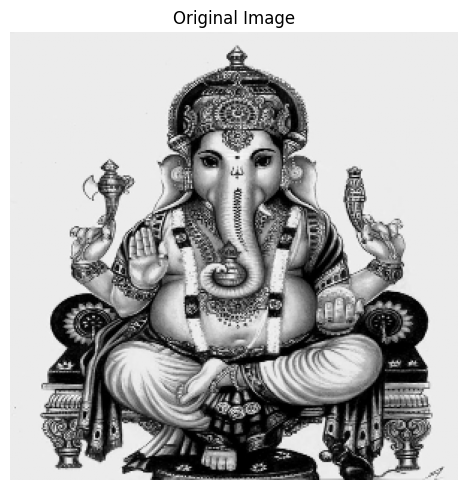

In [6]:
image_path = "God-Image.jpg"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300 ,300])
image = tf.image.convert_image_dtype(image, tf.float32)

print('Original Image Shape:', image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title('Original Image')
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

#### 3. Define Convolution Kernel:
- We define an edge detection filter (Laplacian kernel) to extract important image features.


In [7]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

#### 4. Apply Convolution Layer:
- The convolution layer applies the filter to the image detect edges and features.

After Convolution Shape: (1, 300, 300, 1)


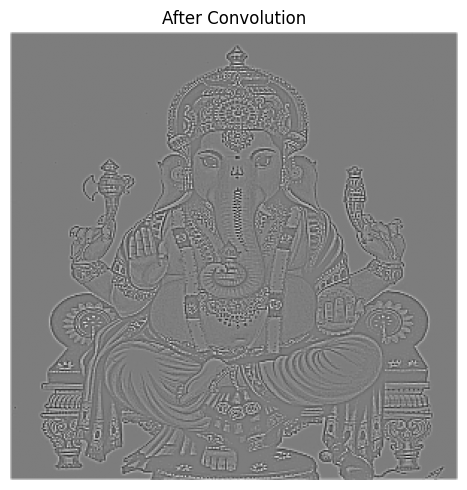

In [8]:
conv_output = tf.nn.conv2d(
    input = image,
    filters=kernel,
    strides=1,
    padding='SAME'
)

print('After Convolution Shape:', conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title('After Convolution')
plt.axis('off')
plt.show()

#### 5. Apply ReLU Activation Function:
- ReLU removes negative values and introduces non-lineaity into the network.

After ReLU Shape: (1, 300, 300, 1)


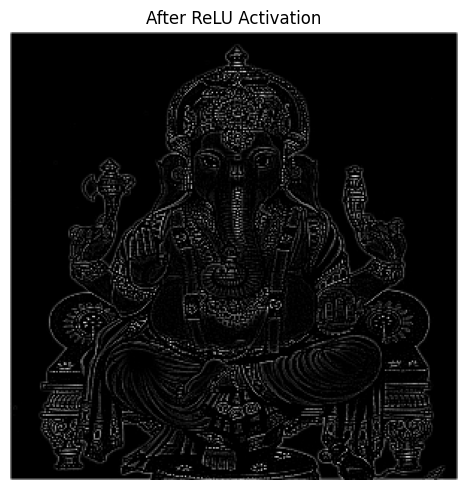

In [9]:
relu_output = tf.nn.relu(conv_output)

print('After ReLU Shape:', relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title('After ReLU Activation')
plt.axis('off')
plt.show()

#### 6. Apply Max Pooling Layer:
- Max pooling reduces spatial dimensions while keeping important features.
  

After Pooling Shape: (1, 150, 150, 1)


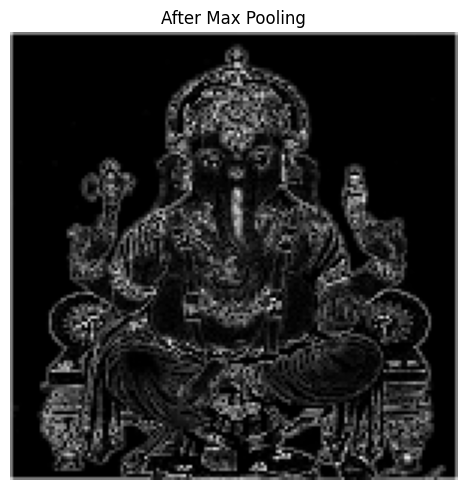

In [11]:
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)

print('After Pooling Shape:', pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title('After Max Pooling')
plt.axis('off')
plt.show()

#### 7. Apply Flatten Layer:
- The flatten layer converts 2D feature maps into a 1D feature vector for fully connected layers.
  

In [13]:
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print('After Flatten Shape:', flatten_output.shape)

print('First 20 Flatten Values:')
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flatten Values:
[1045.5249  642.89    642.      642.      642.      642.      642.
  642.      642.      642.      642.      642.      642.      642.
  642.      642.      642.      642.      642.      642.    ]


#### 8. Add Fully Connected (Dense) Layer:
- The fully connected layers learns high-level patterns from the flattened feature vector and produces output predictions.

In [14]:
dense_layer = tf.keras.layers.Dense(units=64, activation='relu')

dense_output = dense_layer(flatten_output)

print('After Fully Connected Layer Shape:', dense_output.shape)

After Fully Connected Layer Shape: (1, 64)
